[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Recurrent Neural Networks

So far, our networks have processed *fixed-size* inputs: a vector of features, or an image with given dimensions.  Much of the world's data, however, comes in the form of *sequences*:

* A text document is a sequence of words (tokens).
* A patient's hospital stay is a sequence of measurements and events.
* Stock prices form a time series.

There is a wide range of prediction problems associated with sequence data.  Taking text as our running example:

* **Classify** a document, e.g. spam vs. non-spam, or the sentiment of a movie review.
* **Transform** a sequence into another sequence, e.g. translation or part-of-speech tagging.
* **Complete** text, i.e. predict the next token — this is what large language models do!

In this module we focus on *classification*: mapping a varying-length sequence to a single label.  We will return to next-token prediction later in the course, when we discuss language models.

## Why not an MLP?

An MLP expects a fixed number of inputs, but sequences vary in length.  There is a standard way to bridge this gap, and it deserves to be taken seriously before we reject it.  In a **time-delay neural network** (TDNN; Waibel et al., 1989), the input at time $t$ is a *window* of the $k$ most recent tokens — a "tapped delay line" holding $x_{t-k+1}, \ldots, x_t$.  Thlis is then fed into an ordinary feed-forward network that slides along the sequence.  For next-token prediction, the network predicts $x_{t+1}$ from the current window.  This approach has been successful in some applications in speech recognition, such as phoneme recognition where the relevant context (a phoneme's immediate neighbors) is local. Also note that there is a strong analogy to convolutional networks, a technique we will discuss later in the course. 

The fixed window used in TDNNs has significant drawbacks:

* **The context horizon is hard-wired.**  Nothing that occurred more than $k$ steps ago can influence the output, however relevant it is — the delay line simply no longer contains it.  Growing $k$ helps only at the cost of more parameters and more training data, and any fixed choice is defeated by a slightly longer dependency.
* **There is no memory between positions.**  The computation restarts from scratch at every window, so the network has no way to *accumulate* information along the sequence.  The toy problem we study below makes this concrete: deciding whether a sequence contains more `b`s than `a`s requires a running tally over the entire prefix, and no fixed-size window can provide one once sequences are longer than $k$.

What is needed is not a longer window but a summary that *persists*: a fixed-size quantity carried along as the sequence is read, updated at every step, in which the network can store whatever the task requires about everything seen so far.  Giving the network such a summary — a *state* — is exactly the recurrent idea.  Note the progression: CNNs share parameters across positions in space, TDNNs share them across positions in time, and recurrent neural networks (RNNs) share them across time *and* add state, buying — in principle — unbounded context at a fixed parameter cost.

## From text to numbers

Before a neural network can process text, the text is broken into **tokens** — think of them as the LEGO bricks of language.  Tokens can be whole words, parts of words, or punctuation.  Each token is then mapped to an integer **token ID** using a vocabulary, and each ID is finally converted to a vector the network can consume.  We will go through this pipeline in detail for real text in the sentiment analysis notebooks.

In this notebook we keep things minimal: our "language" will have an alphabet of just two tokens, `a` and `b`, and we will represent each token by a one-hot vector.  This lets us concentrate on the recurrent architecture itself, and — more importantly — lets us *look inside* the network and understand what it learns.

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt

torch.manual_seed(0);

## The recurrent idea

An RNN processes a sequence one time step at a time, maintaining a **hidden state** — a vector $\mathbf{H}_t$ that serves as the network's memory of everything it has seen so far.  This is captured in the following architecture:

![An RNN unrolled over time.  At each step the same weights combine the current input with the previous hidden state.](https://github.com/d2l-ai/d2l-en/raw/refs/heads/master/img/rnn.svg)


Let's define the network explicitly.  Assume a minibatch of $n$ sequences, whose time-step-$t$ tokens are represented by the rows of $\mathbf{X}_t \in \mathbb{R}^{n \times d}$.  The hidden state $\mathbf{H}_t \in \mathbb{R}^{n \times h}$ is updated at every step by combining the current input with the previous state:

$$\mathbf{H}_t = \tanh(\mathbf{X}_t \mathbf{W}_{\textrm{xh}} + \mathbf{H}_{t-1} \mathbf{W}_{\textrm{hh}} + \mathbf{b}_\textrm{h}).$$

The number of hidden units $h$ is a hyperparameter.  It sets the size of the network's memory, and it determines the shapes of all the parameters, because every term in the sum must land in the same space as $\mathbf{H}_t \in \mathbb{R}^{n \times h}$.  Thus $\mathbf{W}_{\textrm{xh}} \in \mathbb{R}^{d \times h}$ maps the $d$-dimensional input into the $h$-dimensional hidden space (making $\mathbf{X}_t \mathbf{W}_{\textrm{xh}}$ an $n \times h$ matrix), $\mathbf{W}_{\textrm{hh}} \in \mathbb{R}^{h \times h}$ maps the hidden space to itself, and the bias $\mathbf{b}_\textrm{h} \in \mathbb{R}^{1 \times h}$ is broadcast across the $n$ rows of the minibatch.  You will see exactly these shapes in the `RNNScratch` constructor below.

This simple architecture is known as an **Elman network** (Elman, 1990; see the historical notes at the end of this notebook).  Two things are worth noting:

* The *same* parameters $\mathbf{W}_{\textrm{xh}}, \mathbf{W}_{\textrm{hh}}, \mathbf{b}_\textrm{h}$ are used at every time step.  The number of parameters does not depend on the sequence length, and the network can process sequences of any length.
* All the information about the sequence prefix $\mathbf{X}_1, \ldots, \mathbf{X}_t$ available to the rest of the network is contained in the state $\mathbf{H}_t$.  Whatever the network needs to remember, it must store in this vector.

The figure above shows the network "unrolled" over time: the unrolled computation is just a deep feed-forward network in which the layers share their weights. 
Training is ordinary backpropagation applied to this unrolled graph — in this context it is called **backpropagation through time** (BPTT).

Here is a from-scratch implementation.  The input is a tensor of shape (`num_steps`, `batch_size`, `num_inputs`): a loop over its first axis visits the sequence one time step at a time.

In [2]:
class RNNScratch(nn.Module):
    """An Elman RNN implemented from scratch."""
    def __init__(self, num_inputs, num_hiddens, sigma=0.1):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.W_xh = nn.Parameter(torch.randn(num_inputs, num_hiddens) * sigma)
        self.W_hh = nn.Parameter(torch.randn(num_hiddens, num_hiddens) * sigma)
        self.b_h = nn.Parameter(torch.zeros(num_hiddens))

    def forward(self, inputs, H=None):
        # inputs shape: (num_steps, batch_size, num_inputs)
        if H is None:
            H = torch.zeros(inputs.shape[1], self.num_hiddens,
                            device=inputs.device)
        outputs = []
        for X_t in inputs:  # iterate over time steps
            H = torch.tanh(X_t @ self.W_xh + H @ self.W_hh + self.b_h)
            outputs.append(H)
        # outputs: hidden state at every step; H: final hidden state
        return torch.stack(outputs), H

## A toy classification problem: counting

To understand what an RNN can learn, we start with a task where we know exactly what the *right* solution looks like.

**Task**: given a sequence of tokens from the alphabet $\{\texttt{a}, \texttt{b}\}$, decide whether the sequence contains **more `b`s than `a`s**.  We use sequences of odd length so there are no ties.

A human solving this task would keep a running counter: start at zero, add one for every `b`, subtract one for every `a`, and report the sign of the counter at the end.  Note what this requires from our architecture: the network must *accumulate* information across the whole sequence in its hidden state — no single token or local pattern determines the answer.

Will the RNN discover the counting strategy on its own?  Let's generate some data and find out.  Each token is one-hot encoded: `a` becomes $(1, 0)$ and `b` becomes $(0, 1)$.

In [3]:
def make_counting_data(num_examples, seq_len, seed=0):
    """Random a/b sequences; label 1 if the sequence has more b's than a's."""
    g = torch.Generator().manual_seed(seed)
    tokens = torch.randint(0, 2, (num_examples, seq_len), generator=g)
    labels = (tokens.sum(dim=1) > seq_len // 2).long()
    X = F.one_hot(tokens, num_classes=2).float()  # (N, seq_len, 2)
    return X, labels, tokens

seq_len = 21
X_train, y_train, tokens_train = make_counting_data(4000, seq_len, seed=0)
X_test, y_test, tokens_test = make_counting_data(1000, seq_len, seed=1)
print('X_train:', X_train.shape, ' labels:', y_train[:8].tolist())

batch_size = 64
train_iter = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_train, y_train),
    batch_size=batch_size, shuffle=True)

X_train: torch.Size([4000, 21, 2])  labels: [1, 1, 1, 0, 1, 0, 1, 1]


## From hidden state to prediction

For classification we need to turn the sequence into a single label.  The final hidden state $\mathbf{H}_T$ summarizes the entire sequence, so the simplest approach is to feed it into a linear layer that produces one score (logit) per class — exactly like the output layer of an MLP:

$$\mathbf{O} = \mathbf{H}_T \mathbf{W}_{\textrm{hq}} + \mathbf{b}_\textrm{q}.$$

We train the whole thing end to end with the usual cross-entropy loss.  Note the division of labor that the architecture imposes: the recurrent weights must learn to *maintain a useful summary* of the sequence, and the output layer must learn to *read the answer out* of that summary.

It is worth pausing to separate two things that are easy to conflate — the figure below shows them side by side.  The *RNN itself* (left) is the recurrent chain: it consumes tokens and produces a hidden state at every time step, a representation of the sequence read so far.  The hidden states *are* its output — exactly what our `RNNScratch.forward` returns — and this machinery is task-agnostic.  What we attach to those states is a separate design decision, the **read-out**:

* Apply a (shared) output layer to *every* state (middle) and you get one prediction per position — the shape of sequence tagging and of next-token prediction, i.e., a language model, which we will return to later in the course.
* Apply an output layer to a *summary* of the sequence — here, the final hidden state (right) — and you get a classifier.  (Other summaries work too: the mean of all states, or, in the bidirectional models of the sentiment notebooks, the states at both ends.)

The recurrence and the read-out are trained together, but keeping them conceptually separate pays off well beyond this notebook: it is precisely how large language models are adapted to classification.  An LLM is trained with the per-token read-out of the middle panel — next-token prediction — and to classify with one, you attach a classification head to its representation of the sequence, as in the right panel.  The same move we make here, at a vastly different scale.

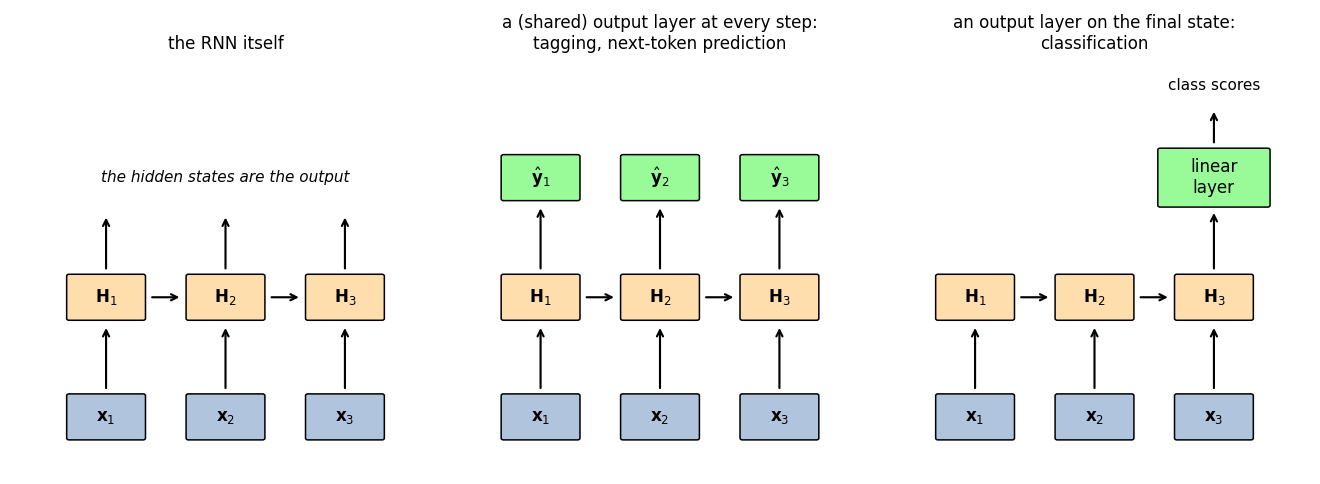

In [ ]:
import matplotlib.patches as mpatches

def draw_rnn(ax, mode):
    T = 3
    def box(x, y, text, fc, w=0.62, h=0.46):
        ax.add_patch(mpatches.FancyBboxPatch(
            (x - w/2, y - h/2), w, h, boxstyle='round,pad=0.02',
            fc=fc, ec='black', lw=1))
        ax.text(x, y, text, ha='center', va='center', fontsize=11)
    def arrow(x0, y0, x1, y1):
        ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle='->', lw=1.4))
    for t in range(T):
        box(t, 0, f'$\\mathbf{{x}}_{t+1}$', 'lightsteelblue')
        box(t, 1.3, f'$\\mathbf{{H}}_{t+1}$', 'navajowhite')
        arrow(t, 0.28, t, 1.0)
        if t:
            arrow(t - 1 + 0.36, 1.3, t - 0.36, 1.3)
    if mode == 'rnn':
        for t in range(T):
            arrow(t, 1.58, t, 2.2)
        ax.text((T - 1) / 2, 2.55, 'the hidden states are the output',
                ha='center', fontsize=10, style='italic')
        ax.set_title('the RNN itself', fontsize=11)
    elif mode == 'step':
        for t in range(T):
            box(t, 2.6, f'$\\hat{{\\mathbf{{y}}}}_{t+1}$', 'palegreen')
            arrow(t, 1.58, t, 2.3)
        ax.set_title('a (shared) output layer at every step:\n'
                     'tagging, next-token prediction', fontsize=11)
    else:
        box(T - 1, 2.6, 'linear\nlayer', 'palegreen', w=0.9, h=0.6)
        arrow(T - 1, 1.58, T - 1, 2.25)
        arrow(T - 1, 2.95, T - 1, 3.35)
        ax.text(T - 1, 3.55, 'class scores', ha='center', fontsize=10)
        ax.set_title('an output layer on the final state:\n'
                     'classification', fontsize=11)
    ax.set_xlim(-0.75, T - 0.25)
    ax.set_ylim(-0.55, 3.9)
    ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(12, 4.4))
for ax, mode in zip(axes, ['rnn', 'step', 'final']):
    draw_rnn(ax, mode)
plt.tight_layout()

In [4]:
class RNNClassifier(nn.Module):
    """Sequence classifier: an RNN followed by a linear read-out layer."""
    def __init__(self, rnn, num_hiddens, num_classes=2):
        super().__init__()
        self.rnn = rnn
        self.decoder = nn.Linear(num_hiddens, num_classes)

    def forward(self, X):
        # X shape: (batch_size, num_steps, num_inputs); the RNN wants
        # the time axis first, so we transpose the first two axes
        outputs, H = self.rnn(X.permute(1, 0, 2))
        return self.decoder(H)

num_hiddens = 4
model = RNNClassifier(RNNScratch(num_inputs=2, num_hiddens=num_hiddens),
                      num_hiddens)

The task is small enough to train on a CPU in well under a minute.  The training loop is the standard one and nothing about it is specific to recurrent networks.

In [5]:
def evaluate_accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1)
    return (preds == y).float().mean().item()

def train(model, train_iter, X_test, y_test, epochs=20, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    loss_train, acc_test = [], []
    for epoch in range(epochs):
        model.train()
        loss_values = []
        for batch_X, batch_y in train_iter:
            loss = loss_fn(model(batch_X), batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_values.append(loss.item())
        loss_train.append(np.mean(loss_values))
        acc_test.append(evaluate_accuracy(model, X_test, y_test))
        print(f'epoch {epoch + 1:2d}  loss {loss_train[-1]:.3f}  '
              f'test accuracy {acc_test[-1]:.3f}')
    return loss_train, acc_test

loss_train, acc_test = train(model, train_iter, X_test, y_test)

epoch  1  loss 0.501  test accuracy 0.914
epoch  2  loss 0.188  test accuracy 0.919
epoch  3  loss 0.173  test accuracy 0.882
epoch  4  loss 0.140  test accuracy 0.948
epoch  5  loss 0.114  test accuracy 0.930
epoch  6  loss 0.142  test accuracy 0.967
epoch  7  loss 0.129  test accuracy 0.959
epoch  8  loss 0.110  test accuracy 0.942
epoch  9  loss 0.096  test accuracy 0.981
epoch 10  loss 0.074  test accuracy 0.971
epoch 11  loss 0.090  test accuracy 0.981
epoch 12  loss 0.070  test accuracy 0.986
epoch 13  loss 0.161  test accuracy 0.912
epoch 14  loss 0.103  test accuracy 0.984
epoch 15  loss 0.072  test accuracy 0.973
epoch 16  loss 0.073  test accuracy 0.981
epoch 17  loss 0.109  test accuracy 0.978
epoch 18  loss 0.091  test accuracy 0.986
epoch 19  loss 0.060  test accuracy 0.943
epoch 20  loss 0.055  test accuracy 0.987


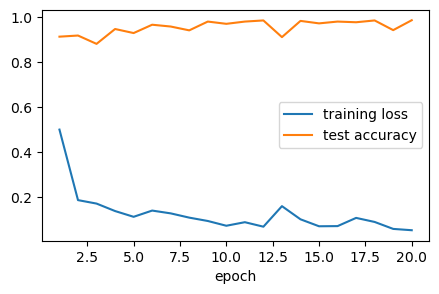

In [6]:
plt.figure(figsize=(5, 3))
plt.plot(range(1, len(loss_train) + 1), loss_train, label='training loss')
plt.plot(range(1, len(acc_test) + 1), acc_test, label='test accuracy')
plt.xlabel('epoch')
plt.legend();

## Looking inside: what did the network learn?

The network solves the task almost perfectly.  Unlike most neural networks we meet, this one is small enough to *open up*: the entire memory of the network is a vector of just a few numbers, and we can watch it evolve token by token.

Let's feed the trained network a few sequences and record the hidden state after every time step.

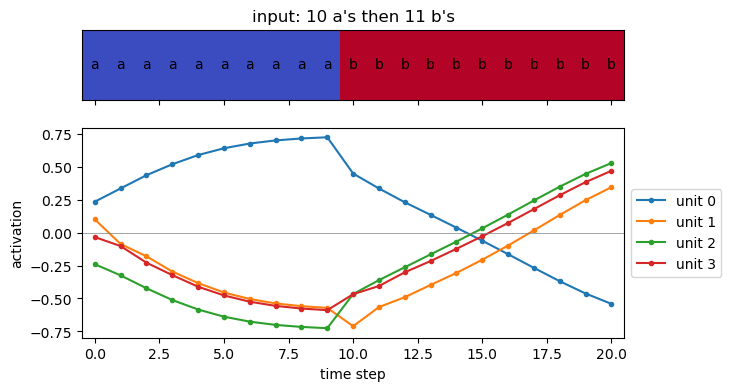

In [7]:
def record_states(model, tokens):
    """Run one sequence through the RNN, returning (seq_len, num_hiddens)."""
    X = F.one_hot(tokens, num_classes=2).float().unsqueeze(0)  # batch of 1
    model.eval()
    with torch.no_grad():
        outputs, H = model.rnn(X.permute(1, 0, 2))
    return outputs.squeeze(1)  # (seq_len, num_hiddens)

def plot_hidden_states(model, tokens, title):
    states = record_states(model, tokens)
    fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True,
                             height_ratios=[1, 3])
    # top: the input sequence
    axes[0].imshow(tokens.reshape(1, -1), cmap='coolwarm', aspect='auto',
                   vmin=0, vmax=1)
    for t, tok in enumerate(tokens):
        axes[0].text(t, 0, 'ab'[tok], ha='center', va='center')
    axes[0].set_yticks([]); axes[0].set_title(title)
    # bottom: hidden units over time
    for i in range(states.shape[1]):
        axes[1].plot(states[:, i], marker='.', label=f'unit {i}')
    axes[1].axhline(0, color='gray', lw=0.5)
    axes[1].set_xlabel('time step'); axes[1].set_ylabel('activation')
    axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5));

# a block of a's followed by a block of b's
tokens_blocks = torch.tensor([0] * 10 + [1] * 11)
plot_hidden_states(model, tokens_blocks, "input: 10 a's then 11 b's")

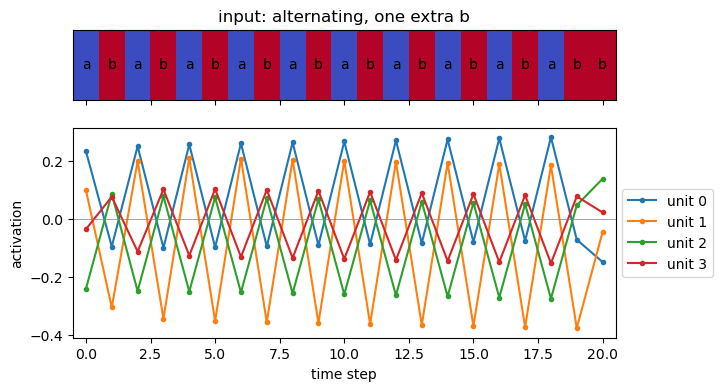

In [8]:
# an alternating sequence with one extra b
tokens_alt = torch.tensor(([0, 1] * 10) + [1])
plot_hidden_states(model, tokens_alt, 'input: alternating, one extra b')

The pictures tell a clear story.  During the run of `a`s, one or more hidden units drift steadily in one direction; when the `b`s begin, they reverse and drift the other way.  On the alternating sequence the same units wiggle up and down around a slowly moving average.  The network has invented a **counter**: each `a` nudges the state one way, each `b` nudges it the other way, and the recurrent weights are tuned to *retain* the accumulated value from step to step.

No one told the network to count.  Counting is simply the solution that gradient descent found, because a running count is the only summary of the prefix that suffices to answer the question at the end.  This is the key intuition for how RNNs learn: **the training signal at the output shapes what the hidden state must remember.**

### How accurate is the counter, really?

Look closely at the block-sequence figure and you will notice something curious: the hidden units cross zero after only about half a dozen `b`s — at which point the sequence still contains more `a`s than `b`s.  An exact counter would not flip until the very last token.  What the network actually learned is a *discounted* count, and the $\tanh$ is to blame.  An exact counter needs the state to move by a fixed increment per token indefinitely, but the $\tanh$ recurrence is a *saturating* integrator: after a handful of consecutive `a`s the relevant units are pressed against their asymptote, and further `a`s barely move them.  Ten `a`s is stored as "many `a`s" — indistinguishable from seven.  When the `b`s begin, each one moves the state by a roughly constant step back from that ceiling, so the crossing comes early.  Equivalently: the network weights recent tokens more heavily than distant ones.

Why did training settle for this?  First, the loss only ever sees the *final* hidden state, so the network pays no penalty for leaning one way in mid-sequence.  Second, a discounted count is nearly as good as an exact one *on the training distribution*: random sequences behave like random walks, whose recent drift and overall majority usually agree.  A perfectly balanced prefix followed by a late flip — precisely the sequence in the figure — is an adversarial ordering that random sampling essentially never produces, so gradient descent had no reason to handle it.  The counter is exactly as accurate as the task demanded, and no more.  (This is also the mechanism behind the accuracy decay on longer sequences that we measure below, and it is what exercise 3 probes.  The LSTM of the next notebook improves matters with a memory that is updated *additively*, free of the squashing nonlinearity.)

We can make the picture even sharper by asking, at every time step, what the output layer *would* decide if the sequence ended right there.  The decoder assigns each class a score; below we plot the difference between the two scores — positive means "more `b`s" — as the network reads a few random test sequences.

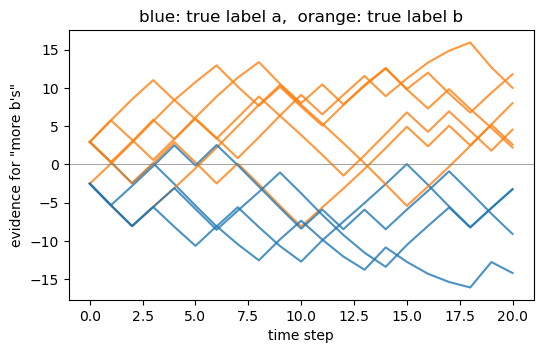

In [9]:
plt.figure(figsize=(6, 3.5))
w = model.decoder.weight.detach()  # (2, num_hiddens)
b = model.decoder.bias.detach()
for i in range(10):
    states = record_states(model, tokens_test[i])
    evidence = states @ (w[1] - w[0]) + (b[1] - b[0])
    color = 'C1' if y_test[i] == 1 else 'C0'
    plt.plot(evidence, color=color, alpha=0.8)
plt.axhline(0, color='gray', lw=0.5)
plt.xlabel('time step')
plt.ylabel('evidence for "more b\'s"')
plt.title('blue: true label a,  orange: true label b');

Each curve is a random test sequence, colored by its true label.  The network *accumulates evidence* token by token: every `b` pushes the curve up, every `a` pushes it down, and by the end of the sequence the two classes have separated.  Early in the sequence the curves crisscross — the outcome is still undecided — and they diverge as the count becomes conclusive.

Finally, let's look at where complete sequences end up in the hidden space.  Each point below is the final hidden state of one test sequence, shown for the two hidden units with the largest weight in the decoder.

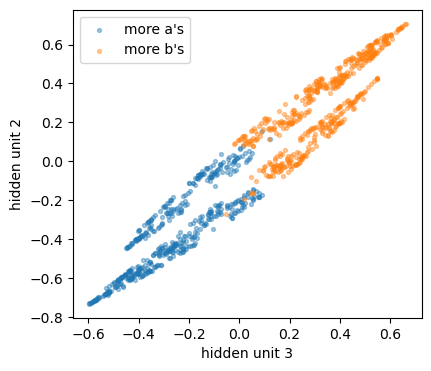

In [10]:
with torch.no_grad():
    _, H_final = model.rnn(X_test.permute(1, 0, 2))
# pick the two hidden units the decoder relies on most
imp = (model.decoder.weight[1] - model.decoder.weight[0]).abs()
u1, u2 = torch.topk(imp, 2).indices.tolist()
plt.figure(figsize=(4.5, 4))
for label, color, name in [(0, 'C0', "more a's"), (1, 'C1', "more b's")]:
    mask = y_test == label
    plt.scatter(H_final[mask, u1], H_final[mask, u2], s=8, alpha=0.4,
                color=color, label=name)
plt.xlabel(f'hidden unit {u1}'); plt.ylabel(f'hidden unit {u2}')
plt.legend();

The two classes form well-separated clouds: by the last time step, the hidden state has turned a *sequential* problem into an ordinary *linearly separable* one, which the output layer solves with a single hyperplane.  This is the general recipe for sequence classification with RNNs — the recurrence converts a varying-length sequence into a fixed-length vector that makes the classes separable.

## Does the counter generalize?

A network that truly counts should work on sequences *longer* than any it was trained on.  Our model was trained only on length-21 sequences; let's test it on longer ones without any retraining — something that would be impossible with the flattened-MLP approach.

In [11]:
for L in [21, 41, 81, 161]:
    X_long, y_long, _ = make_counting_data(1000, L, seed=2)
    print(f'length {L:3d}: accuracy {evaluate_accuracy(model, X_long, y_long):.3f}')

length  21: accuracy 0.992
length  41: accuracy 0.941
length  81: accuracy 0.816
length 161: accuracy 0.719


Accuracy typically stays well above chance on sequences several times longer than the training length, though it degrades as sequences get much longer — the learned counter is implemented with saturating $\tanh$ units and is not a perfect integrator.  How to build recurrent units that hold information reliably over long spans is exactly the topic of the next notebook.

## Concise implementation

PyTorch provides the recurrent layer as `nn.RNN`.  It implements exactly the update equation of our `RNNScratch` (and runs faster, since the time loop happens in compiled code).  Like our version, it expects input of shape (`num_steps`, `batch_size`, `num_inputs`) and returns the outputs at every step together with the final state.

In [12]:
class RNNConciseClassifier(nn.Module):
    def __init__(self, num_inputs, num_hiddens, num_classes=2):
        super().__init__()
        self.rnn = nn.RNN(num_inputs, num_hiddens)
        self.decoder = nn.Linear(num_hiddens, num_classes)

    def forward(self, X):
        outputs, H = self.rnn(X.permute(1, 0, 2))
        return self.decoder(H[-1])  # H has an extra leading layer axis

model_concise = RNNConciseClassifier(num_inputs=2, num_hiddens=num_hiddens)
loss_train, acc_test = train(model_concise, train_iter, X_test, y_test,
                             epochs=10)

epoch  1  loss 0.582  test accuracy 0.876
epoch  2  loss 0.252  test accuracy 0.911
epoch  3  loss 0.190  test accuracy 0.934
epoch  4  loss 0.176  test accuracy 0.952
epoch  5  loss 0.131  test accuracy 0.956
epoch  6  loss 0.093  test accuracy 0.968
epoch  7  loss 0.081  test accuracy 0.963
epoch  8  loss 0.085  test accuracy 0.880
epoch  9  loss 0.107  test accuracy 0.975
epoch 10  loss 0.095  test accuracy 0.916


## The trouble with long sequences

Training an RNN means backpropagating through the unrolled network — one layer per time step.  For a sequence of length 500 (a typical movie review), the gradient signal from the loss must pass through 500 applications of the recurrent update.  At each step it gets multiplied by the recurrent weight matrix (and by the derivative of the $\tanh$, which is at most 1).  Repeated multiplication makes the gradient shrink or grow *geometrically*:

* If the relevant factors are slightly less than one, the gradient **vanishes** — the network gets essentially no signal about how early tokens should influence the answer, and it "forgets" the beginning of the sequence.
* If they are greater than one, the gradient **explodes** — training becomes unstable.

The figure below makes the geometry of the problem explicit.  Unrolled, the network is a deep chain with the teaching signal — the loss — at one end.  To adjust how an early input is processed, the gradient must travel back along the chain, and each step of distance adds one more multiplication by the same kind of factor:

$$\frac{\partial L}{\partial \mathbf{H}_t} \;=\; \frac{\partial L}{\partial \mathbf{H}_T}\,\frac{\partial \mathbf{H}_T}{\partial \mathbf{H}_{T-1}}\cdots\frac{\partial \mathbf{H}_{t+1}}{\partial \mathbf{H}_t},$$

one factor — essentially $\mathbf{W}_{\textrm{hh}}$, damped by the $\tanh$ derivative — per step of separation.  An input five steps from the loss is reached through five such factors; an input 100 steps away, through 100.  A number raised to the 100th power is either enormous or negligible: exponential behavior in the *distance* is built into the unrolled architecture.

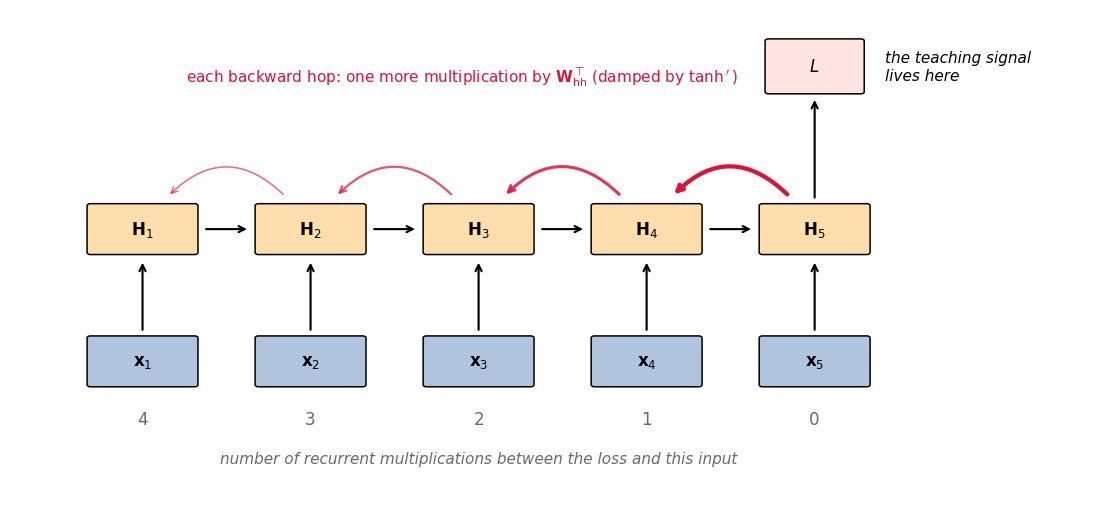

In [ ]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 4.6))
T = 5

def box(x, y, text, fc, w=0.62, h=0.46):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h, boxstyle='round,pad=0.02',
        fc=fc, ec='black', lw=1))
    ax.text(x, y, text, ha='center', va='center', fontsize=11)

def arrow(x0, y0, x1, y1, color='black', lw=1.4, rad=0.0, alpha=1.0):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', lw=lw, color=color,
                                alpha=alpha,
                                connectionstyle=f'arc3,rad={rad}'))

# the unrolled forward chain
for t in range(T):
    box(t, 0, f'$\\mathbf{{x}}_{t+1}$', 'lightsteelblue')
    box(t, 1.3, f'$\\mathbf{{H}}_{t+1}$', 'navajowhite')
    arrow(t, 0.28, t, 1.0)
    if t:
        arrow(t - 1 + 0.36, 1.3, t - 0.36, 1.3)

# the loss sits at the end of the sequence
box(T - 1, 2.9, '$L$', 'mistyrose', w=0.55, h=0.5)
arrow(T - 1, 1.58, T - 1, 2.6)
ax.text(T - 1 + 0.42, 2.9, 'the teaching signal\nlives here',
        fontsize=10, style='italic', va='center')

# the backward path: the gradient fades with every hop
for k in range(1, T):
    src, dst = T - k, T - k - 1
    fade = 0.85 ** (k - 1)
    arrow(src - 0.15, 1.62, dst + 0.15, 1.62, color='crimson',
          lw=2.8 * fade**2, rad=0.5, alpha=min(1, fade))
ax.text((T - 2) / 2 + 0.4, 2.75,
        'each backward hop: one more multiplication by '
        "$\\mathbf{W}_{\\mathrm{hh}}^{\\top}$ (damped by $\\tanh'\\,$)",
        ha='center', fontsize=10, color='crimson')

for t in range(T):
    ax.text(t, -0.62, f'{T - 1 - t}', ha='center', fontsize=11,
            color='dimgray')
ax.text((T - 1) / 2, -1.0,
        'number of recurrent multiplications between the loss and this input',
        ha='center', fontsize=10, color='dimgray', style='italic')

ax.set_xlim(-0.75, T + 0.6)
ax.set_ylim(-1.25, 3.4)
ax.axis('off')
plt.tight_layout()

These claims are easy to verify — an advantage of a from-scratch implementation is that we can hold on to the intermediate hidden states and ask autograd for the gradient of the loss with respect to each one.  In the left panel below, we feed a single length-100 sequence to three networks and plot $\|\partial L/\partial \mathbf{H}_{T-k}\|$ against $k$, the number of steps *back* from the loss — which, as the figure above shows, is the number of recurrent multiplications the signal has passed through.  In the right panel we isolate the mechanism: with a silent (all-zero) input the state stays at the origin, $\tanh$ operates in its linear regime, and backpropagation reduces to repeated multiplication by $\mathbf{W}_{\textrm{hh}}^\top$.

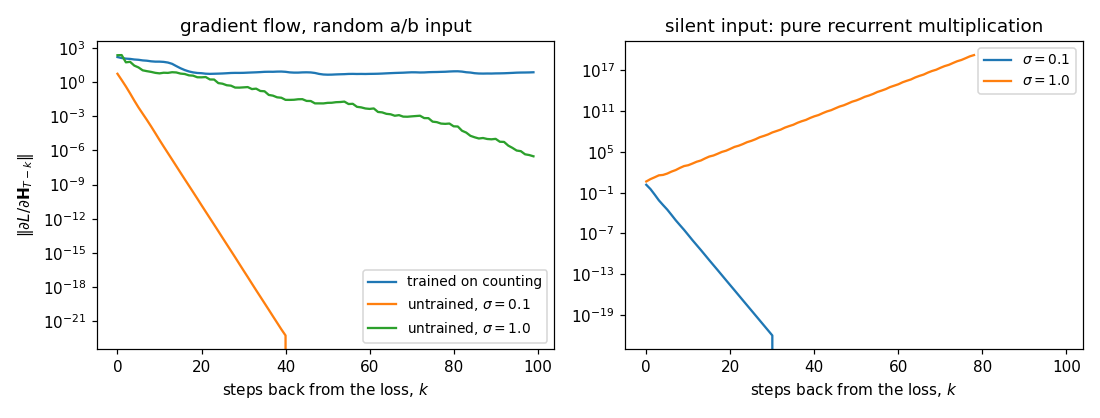

In [ ]:
def state_grad_norms(rnn, decoder, seq_len=100, seed=5):
    """Backprop from a loss on the final state; record ||dL/dH_t|| for all t."""
    g = torch.Generator().manual_seed(seed)
    tokens = torch.randint(0, 2, (1, seq_len), generator=g)
    X = F.one_hot(tokens, num_classes=2).float().permute(1, 0, 2)
    H = torch.zeros(1, rnn.num_hiddens)
    states = []
    for X_t in X:
        H = torch.tanh(X_t @ rnn.W_xh + H @ rnn.W_hh + rnn.b_h)
        H.retain_grad()   # keep the gradient of this intermediate state
        states.append(H)
    decoder(states[-1]).square().sum().backward()
    # reverse so that index k = number of steps back from the loss
    return [h.grad.norm().item() for h in states][::-1]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for label, rnn in [
        ('trained on counting', model.rnn),
        ('untrained, $\\sigma=0.1$', RNNScratch(2, num_hiddens, sigma=0.1)),
        ('untrained, $\\sigma=1.0$', RNNScratch(2, num_hiddens, sigma=1.0))]:
    axes[0].semilogy(state_grad_norms(rnn, model.decoder), label=label)
axes[0].set_xlabel('steps back from the loss, $k$')
axes[0].set_ylabel('$\\|\\partial L/\\partial \\mathbf{H}_{T-k}\\|$')
axes[0].set_title('gradient flow, random a/b input')
axes[0].legend(fontsize=9)

torch.manual_seed(1)
for sigma in [0.1, 1.0]:
    W = torch.randn(num_hiddens, num_hiddens) * sigma
    W.requires_grad_(True)
    H = torch.zeros(1, num_hiddens)
    states = []
    for t in range(100):
        H = torch.tanh(H @ W)   # silent input: pure recurrent multiplication
        H.retain_grad()
        states.append(H)
    (states[-1] @ torch.randn(num_hiddens)).sum().backward()
    axes[1].semilogy([h.grad.norm().item() for h in states][::-1],
                     label=f'$\\sigma={sigma}$')
axes[1].set_xlabel('steps back from the loss, $k$')
axes[1].set_title('silent input: pure recurrent multiplication')
axes[1].legend(fontsize=9)
plt.tight_layout()

Note the logarithmic scale.  For the freshly initialized network with a typical small initialization ($\sigma = 0.1$) — the condition in which all learning must begin — the gradient decays by more than twenty orders of magnitude over the sequence, underflowing to zero about forty steps back from the loss.  An input 100 steps before the read-out contributes nothing to the parameter updates: the network cannot learn what it cannot feel.  Larger random weights ($\sigma = 1.0$) decay more slowly on this run, but with real inputs large weights also saturate the $\tanh$, whose near-zero derivative crushes the gradient — vanishing again, by another route.

The trained counting network is the interesting exception: it transmits gradients across all 100 steps essentially undiminished.  The counting task requires remembering the entire sequence, so training drove the recurrent dynamics to the edge of stability — a recurrent gain of almost exactly one.  But notice the bootstrap problem this reveals: the network could only learn this because its training sequences were short (21 steps), within reach of the initial gradient signal.  The signal needed to *learn* to remember over long spans is precisely the signal that vanishes.

The right panel completes the picture: repeated multiplication by a fixed matrix either shrinks the gradient geometrically (recurrent gain below one) or amplifies it past $10^{17}$ and on to overflow (gain above one).  A generic $\mathbf{W}_{\textrm{hh}}$ does one or the other; neither is what learning needs.

Exploding gradients have a crude but effective fix, *gradient clipping* (rescaling the gradient when its norm exceeds a threshold).  Vanishing gradients are the deeper problem, and solving it requires changing the architecture itself.  That is the subject of the next notebook, on **long short-term memory** (LSTM) networks.

## A bit of history

Recurrent networks are almost exactly as old as backpropagation itself.  The 1986 work that popularized backpropagation (Rumelhart, Hinton & Williams, 1986) already showed how to train networks with cycles by unfolding them in time — the idea now called *backpropagation through time*, analyzed systematically by Werbos (1990), with an online variant by Williams & Zipser (1989).  Architectures followed immediately: Jordan (1986) fed the network's previous *output* back in as input, and Elman (1990), in "Finding structure in time", moved the feedback to the hidden state, giving the architecture used in this notebook.  The near-simultaneity is no accident — sequences were the obvious frontier the moment gradient training of nonlinear networks became practical.  It took most of a decade longer to understand why these networks were so hard to train on long sequences (Bengio, Simard & Frasconi, 1994), a difficulty that set the agenda for the LSTM (Hochreiter & Schmidhuber, 1997).

**References**

* Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. *Nature*, 323, 533–536.  (The companion chapter in the PDP volumes, "Learning internal representations by error propagation", spells out the unfolding-in-time construction.)
* Jordan, M. I. (1986). Serial order: A parallel distributed processing approach. ICS Report 8604, UC San Diego.
* Elman, J. L. (1990). Finding structure in time. *Cognitive Science*, 14(2), 179–211.
* Williams, R. J., & Zipser, D. (1989). A learning algorithm for continually running fully recurrent neural networks. *Neural Computation*, 1(2), 270–280.
* Werbos, P. J. (1990). Backpropagation through time: what it does and how to do it. *Proceedings of the IEEE*, 78(10), 1550–1560.
* Waibel, A., Hanazawa, T., Hinton, G., Shikano, K., & Lang, K. J. (1989). Phoneme recognition using time-delay neural networks. *IEEE Transactions on Acoustics, Speech, and Signal Processing*, 37(3), 328–339.
* Bengio, Y., Simard, P., & Frasconi, P. (1994). Learning long-term dependencies with gradient descent is difficult. *IEEE Transactions on Neural Networks*, 5(2), 157–166.
* Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation*, 9(8), 1735–1780.

## Summary

* RNNs process a sequence one step at a time, carrying information in a hidden state; the same weights are applied at every step, so any-length sequences can be handled with a fixed number of parameters.
* For classification, the final hidden state is a fixed-length summary of the sequence, which a linear layer maps to class scores; the whole model is trained end to end with backpropagation through time.
* On the counting task the network learns an interpretable strategy: hidden units act as accumulators, and the prediction reflects evidence accumulated across the entire sequence.  The hidden state learns to store *whatever the output needs*.
* Vanilla RNNs struggle to carry information across long sequences because gradients vanish (or explode) when backpropagated through many time steps.

## Exercises

1. **Parity.**  Change the labels so a sequence is positive if it contains an *odd number* of `b`s, and retrain.  This task also has a tiny exact solution — a one-bit "flip-flop" that toggles on every `b`.  Visualize the hidden state: can you find the flip-flop?  Is parity easier or harder to learn than counting?
2. Retrain the counting model with `num_hiddens=1`.  Does a single unit suffice?  Look at the hidden state trajectory of the trained model.
3. On the counting task, evaluate the model only on *hard* sequences where the counts differ by exactly one.  How does the accuracy change?  What does this say about what the hidden state stores — an exact count, or something noisier?
4. Replace the final-state read-out with a read-out based on the *mean* of the hidden states over time.  Does it work as well?  Why might averaging help for very long sequences?